# 02 — Volumes, a contact scenario, and view bundles

Reading volumetrics off a `StaticModel`: a per-zone **GRV / in-place** table, a **contact scenario** (deepen a zone's OWC -> more oil), and a peek at the JSON **view bundles** the model emits for downstream viewers — including a small areal porosity map rendered from the map bundle.

> **Note — Python surface.** petekStatic is a Rust workspace. A minimal own wheel
> (`petekstatic`, `build_flat_model`) is landing, but the rich geomodel workflow
> shown here — scatter-conditioned horizon stacks, multi-zone volumes, contact
> scenarios — runs through the **`peteksim` facade**, which *is* petekStatic's
> engine (petekSim re-exports petekStatic's crates one layer down in the DAG).
> All data below is **synthetic**; nothing references any real dataset.

## 1. Build the model (same synthetic scatter stack as notebook 01)

In [1]:
import json, tempfile
import peteksim as ps

# A deterministic synthetic asset with horizons AS SCATTER POINTS. Passing
# surfaces_as_points=True routes petekStatic's `from_scatter` conditioning path:
# the raw points are conditioned onto the build frame, then resolved as a stack.
root = tempfile.mkdtemp(prefix="synth_stack_")   # a throwaway temp dir
man  = ps.synth_asset(root, surfaces_as_points=True, seed=20260704, ncol=41)

proj = ps.Project.load(
    man["root"], settings=ps.LoadSettings(crs=man["crs"], aliases=man["aliases"]))

# N horizons -> N-1 zones; convergent well ties; collapse negative thickness.
hz = ps.Horizons(
    *[ps.hz(h) for h in man["horizons"]],
    zones=man["zones"],
    ties=ps.TieSettings(method="convergent"),
    gridding=ps.Gridding(collapse=True),
)
lay = ps.Layering(nk=2)

# Per-zone fluid contacts, straight from the synthetic zonation.
con = ps.Contacts({z["zone"]: dict(z["contacts"])
                   for z in man["zonation"] if z["contacts"]})

# Two deterministic property cubes: net-only porosity + net-to-gross,
# each variogram-propagated from a fixed seed.
props = ps.Props(
    ps.Prop("PORO", net_only=True,
            propagate=ps.Propagate(variogram=ps.variogram("spherical", 1500.0), seed=11)),
    ps.Prop("NTG",
            propagate=ps.Propagate(variogram=ps.variogram("spherical", 1500.0), seed=12)),
)

# Grid construction: a 50 m x 50 m corner-point grid on the georeferenced frame.
geom = proj.grid_geometry(cell=(50.0, 50.0), orient=0.0)
grid = geom.build(hz, layering=lay, collapse_negative=True, min_thickness_m=0.0)

# Populate + attach contacts + fluids -> a StaticModel you can read volumes off.
model = grid.model(props, con, fluid="oil", fvf=1.30, gas_fvf=0.005)
print("StaticModel built:", len(man["zones"]), "zones,",
      "properties:", model.property_names())


StaticModel built: 6 zones, properties: ['SW', 'PORO', 'NTG']


## 2. Per-zone GRV / in-place table

The full breakdown: gross rock volume, hydrocarbon pore volume, and STOIIP per zone, plus the rollup total.

In [2]:
byzone = model.in_place_by_zone()
rows   = byzone["zones"]
total  = byzone["total"]

hdr = f'{"zone":6} {"GRV[Mm3]":>10} {"HCPV[m3]":>14} {"STOIIP[MSm3]":>13}'
print(hdr); print("-" * len(hdr))
for z in rows:
    print(f'{z["zone"]:6} {z["grv_mcm"]:>10.2f} {z["hcpv_m3"]:>14.1f} '
          f'{z["stoiip_msm3"]:>13.4f}')
print("-" * len(hdr))
print(f'{"TOTAL":6} {total["grv_mcm"]:>10.2f} {total["hcpv_m3"]:>14.1f} '
      f'{total["stoiip_msm3"]:>13.4f}')


zone     GRV[Mm3]       HCPV[m3]  STOIIP[MSm3]
----------------------------------------------
Z0         247.87            0.0        0.0000
Z1         193.40            0.0        0.0000
Z2           1.11       149560.1        0.1150
Z3         142.45            0.0        0.0000
Z4           1.09       143630.9        0.1105
Z5         109.01            0.0        0.0000
----------------------------------------------
TOTAL      694.95       293191.0        0.2255


## 3. A contact scenario — deepen an OWC

`Contacts.replace` derives a **new** contact set (the original is immutable). We pick the oil-bearing zone and push its oil-water contact deeper: a deeper OWC means a taller oil column, so more rock is above the contact and STOIIP rises. We rebuild the model on the new contacts and compare.

In [3]:
# The oil zone in this synthetic asset is the one with an OWC contact.
oil_zone = next(z["zone"] for z in man["zonation"]
                if z["contacts"] and "owc" in z["contacts"])
base_owc = con.for_zone(oil_zone)["owc"]
deep_owc = base_owc + 40.0     # push the contact 40 m deeper

con_deep   = con.replace(oil_zone, owc=deep_owc)
model_deep = grid.model(props, con_deep, fluid="oil", fvf=1.30, gas_fvf=0.005)

def zone_stoiip(m, zone):
    return next(z["stoiip_msm3"] for z in m.in_place_by_zone()["zones"]
               if z["zone"] == zone)

base_v = zone_stoiip(model, oil_zone)
deep_v = zone_stoiip(model_deep, oil_zone)
print(f"zone {oil_zone}:")
print(f"  base OWC {base_owc:7.1f} m -> STOIIP {base_v:.4f} MSm3")
print(f"  deep OWC {deep_owc:7.1f} m -> STOIIP {deep_v:.4f} MSm3")
print(f"  uplift: x{deep_v / base_v:.1f}  (+{deep_v - base_v:.4f} MSm3)")


zone Z2:
  base OWC  1951.4 m -> STOIIP 0.1150 MSm3
  deep OWC  1991.4 m -> STOIIP 7.4402 MSm3
  uplift: x64.7  (+7.3252 MSm3)


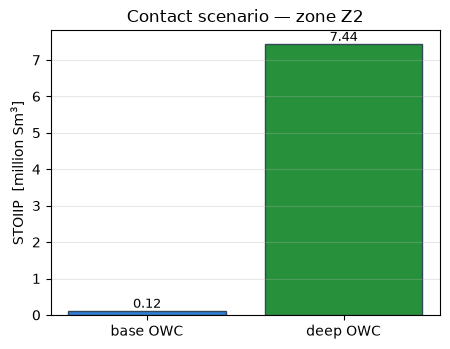

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.6, 3.6))
ax.bar(["base OWC", "deep OWC"], [base_v, deep_v],
       color=["#2f7ed8", "#26913a"], edgecolor="#33475b")
ax.set_ylabel("STOIIP  [million Sm$^3$]")
ax.set_title(f"Contact scenario — zone {oil_zone}")
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate([base_v, deep_v]):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
plt.show()


## 4. View bundles

The model emits self-contained JSON **bundles** for downstream viewers. Here we peek at the *shape* of two of them — we never dump the payload.

- `volume_bundle(property)` — the corner-point exterior shell (a triangulated 3-D envelope with base64-wrapped binary blocks).
- `map_bundle(property)` — the areal (plan-view) bundle: a georeferenced raster `frame` plus per-zone average maps.

In [5]:
vb = model.volume_bundle(property="PORO")
mb = model.map_bundle(property="PORO")

print("volume_bundle keys:", sorted(vb.keys()))
print("  property     :", vb["property"])
print("  cell_count   :", vb["cell_count"])
print("  triangles    :", vb["triangle_count"])
print("  encoding     :", vb["encoding"])
print()
print("map_bundle keys   :", sorted(mb.keys()))
fr = mb["frame"]
print(f'  frame        : {fr["ncol"]} x {fr["nrow"]} cells, '
      f'{fr["spacing_x"]:.0f} m spacing')
print("  zone_averages:", len(mb["zone_averages"]), "maps")


volume_bundle keys: ['blocks', 'cell_count', 'encoding', 'inputs_ref', 'kind', 'property', 'schema_version', 'shell_cell_count', 'triangle_count', 'value_range', 'vertex_count', 'zone_names']
  property     : PORO
  cell_count   : 76800
  triangles    : 35776
  encoding     : base64

map_bundle keys   : ['contacts', 'frame', 'horizons', 'inputs_ref', 'k_slices', 'outline', 'schema_version', 'wells', 'zone_averages']
  frame        : 80 x 80 cells, 50 m spacing
  zone_averages: 6 maps


## 5. Render an areal porosity map from the bundle

The map bundle carries a georeferenced `frame` and, per zone, an array of average values on that frame. We reshape one zone's array to the frame and draw it — a self-contained areal PORO map straight from the bundle.

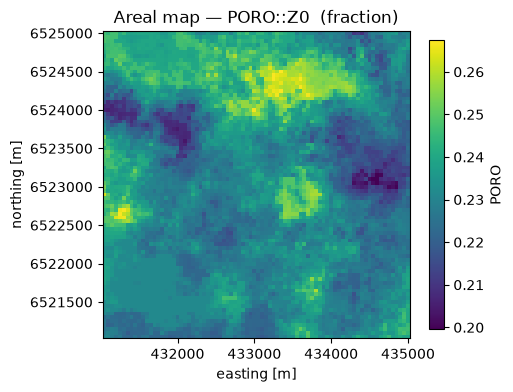

PORO::Z0: 0.200 .. 0.267 fraction


In [6]:
import numpy as np

fr   = mb["frame"]
ncol, nrow = fr["ncol"], fr["nrow"]

# Pick a zone-average map that has real (non-empty) coverage.
za = next(z for z in mb["zone_averages"]
          if any(np.isfinite(v) for v in z["values"]))
grid_vals = np.array(za["values"], dtype=float).reshape(nrow, ncol)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
extent = [fr["origin_x"], fr["origin_x"] + ncol * fr["spacing_x"],
          fr["origin_y"], fr["origin_y"] + nrow * fr["spacing_y"]]
im = ax.imshow(grid_vals, origin="lower", extent=extent,
               cmap="viridis", aspect="equal")
ax.set_title(f'Areal map — {za["name"]}  ({za["units"]})')
ax.set_xlabel("easting [m]"); ax.set_ylabel("northing [m]")
ax.ticklabel_format(style="plain")
fig.colorbar(im, ax=ax, shrink=0.8, label=za["property"])
fig.tight_layout()
plt.show()

vmin, vmax = za["range"]["min"], za["range"]["max"]
print(f'{za["name"]}: {vmin:.3f} .. {vmax:.3f} {za["units"]}')


## Recap

We read a per-zone GRV / in-place table off the `StaticModel`, ran a **contact scenario** by deriving a deeper OWC and rebuilding, and inspected the JSON view bundles — including rendering an areal porosity map from the map bundle's georeferenced frame. These are the volumetrics + view seams petekStatic hands to petekSim.